<a href="https://colab.research.google.com/github/latiyan09/Deep-Learning/blob/main/Admission_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 8.1 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [2]:
import os
import json
from google.colab import userdata

# Ensure the .kaggle directory exists
!mkdir -p ~/.kaggle

# Read the kaggle.json content from Colab secrets
kaggle_config_data = userdata.get('KAGGLE_CONFIG_DATA')

# Write the content to kaggle.json file
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_config_data)

# Set correct permissions
!chmod 600 /root/.kaggle/kaggle.json

print('Kaggle API key configured successfully!')

Kaggle API key configured successfully!


In [3]:
# Download the dataset files to the current working directory
!kaggle datasets download -d 'mohansacharya/graduate-admissions'


print('Dataset downloaded and unzipped successfully!')

Dataset URL: https://www.kaggle.com/datasets/mohansacharya/graduate-admissions
License(s): CC0-1.0
100% 9.64k/9.64k [00:00<00:00, 3.73MB/s]

Dataset downloaded and unzipped successfully!


In [4]:
!unzip -o graduate-admissions.zip

Archive:  graduate-admissions.zip
  inflating: Admission_Predict.csv   
  inflating: Admission_Predict_Ver1.1.csv  


In [5]:
import pandas as pd

df = pd.read_csv('Admission_Predict_Ver1.1.csv') # Or test.csv, depending on what was unzipped
df.head(5)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [6]:
df.shape

(500, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [8]:
df.columns.to_list()

['Serial No.',
 'GRE Score',
 'TOEFL Score',
 'University Rating',
 'SOP',
 'LOR ',
 'CGPA',
 'Research',
 'Chance of Admit ']

In [9]:
df.corr()['Chance of Admit ']

,Chance of Admit
Serial No.,0.008505
GRE Score,0.810351
TOEFL Score,0.792228
University Rating,0.690132
SOP,0.684137
LOR,0.645365
CGPA,0.882413
Research,0.545871
Chance of Admit,1.000000


In [10]:
df.drop(columns=['Serial No.'],inplace=True)

In [40]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [11]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [12]:
x.shape

(500, 7)

In [13]:
y.shape

(500,)

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [15]:
x_train.shape

(400, 7)

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [17]:
x_train_scaled

array([[0.4       , 0.42857143, 0.5       , ..., 0.57142857, 0.50320513,
        0.        ],
       [0.56      , 0.64285714, 0.        , ..., 0.57142857, 0.55769231,
        1.        ],
       [0.2       , 0.32142857, 0.5       , ..., 0.28571429, 0.34615385,
        0.        ],
       ...,
       [0.7       , 0.53571429, 0.5       , ..., 0.57142857, 0.74038462,
        1.        ],
       [0.72      , 0.67857143, 1.        , ..., 0.71428571, 0.77884615,
        1.        ],
       [0.2       , 0.46428571, 0.        , ..., 0.14285714, 0.32051282,
        0.        ]])

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [19]:
model = Sequential()

model.add(Input(shape=(7,)))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='linear'))

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer='Adam',loss='mean_squared_error',metrics = ['accuracy'])

In [25]:
history = model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0000e+00 - loss: 0.0035 - val_accuracy: 0.0000e+00 - val_loss: 0.0035
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 0.0034 - val_accuracy: 0.0000e+00 - val_loss: 0.0040
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 0.0035 - val_accuracy: 0.0000e+00 - val_loss: 0.0034
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 0.0033 - val_accuracy: 0.0000e+00 - val_loss: 0.0035
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 0.0033 - val_accuracy: 0.0000e+00 - val_loss: 0.0036
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 0.0033 - val_accuracy: 0.0000e+00 - val_loss: 0.0035
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 0.0033 - val_accuracy: 0.0000e+00 - val_loss: 0.0035
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - a

In [26]:
model.predict(x_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[0.6432891 ],
       [0.691368  ],
       [0.92075694],
       [0.7070774 ],
       [0.81116927],
       [0.6644844 ],
       [0.7275096 ],
       [0.6975112 ],
       [0.76343095],
       [0.6454602 ],
       [0.67685395],
       [0.54880697],
       [0.75141793],
       [0.7775588 ],
       [0.7492076 ],
       [0.865441  ],
       [0.62969166],
       [0.7519869 ],
       [0.9117428 ],
       [0.66927224],
       [0.615992  ],
       [0.7953255 ],
       [0.8356887 ],
       [0.50944096],
       [0.77829385],
       [0.62637407],
       [0.946586  ],
       [0.64562166],
       [0.8398573 ],
       [0.6917783 ],
       [0.63780415],
       [0.7919596 ],
       [0.5965525 ],
       [0.8850628 ],
       [0.6110709 ],
       [0.7962971 ],
       [0.6760185 ],
       [0.64882225],
       [0.64558357],
       [0.8954021 ],
       [0.49643886],
       [0.6555115 ],
       [0.6992047 ],
       [0.9640471 ],
       [0.7503852 ],
       [0.4982757 ],
       [0.6455431 ],
       [0.613

In [27]:
from sklearn.metrics import r2_score
y_pred = model.predict(x_test_scaled)
r2_score(y_test,y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


0.8063414306289293

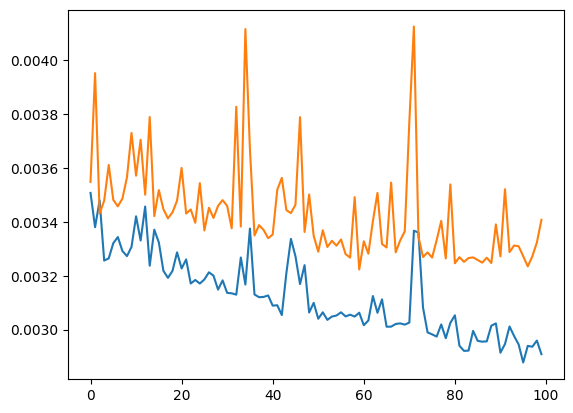

In [28]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
